# <center>Generalized least squares</center>
### <center>Alfred Galichon (NYU)</center>
## <center>'math+econ+code' masterclass series: econometrics</center>
#### <center>With python code examples</center>

© 2018–2026 by Alfred Galichon. Past and present support from NSF grant DMS-1716489, ERC grant CoG-866274 are acknowledged, as well as inputs from contributors listed [here](http://www.math-econ-code.org/team).

**If you reuse material from this masterclass, please cite as:**<br>
Alfred Galichon, 'math+econ+code' masterclass series. https://www.math-econ-code.org/

### Learning objectives

* Replace the spherical-error assumption (A3) of Lecture 3 by $\operatorname{Var}(\varepsilon\mid X) = \sigma^2\Omega$ with $\Omega$ known, and derive the **generalized least squares** (GLS) estimator as OLS on a whitened model.

* State and prove **Aitken's theorem**, GLS is BLUE under non-spherical errors, and verify numerically that the Gauss–Markov ranking $\operatorname{Var}(\hat\beta_{\text{OLS}}) - \operatorname{Var}(\hat\beta_{\text{GLS}}) \succeq 0$ holds in a designed experiment.

* Specialize to **weighted least squares** when $\Omega$ is diagonal, and see on grouped Mroz data that WLS on cell means reproduces the micro-data OLS estimate exactly while unweighted cell regression does not.

* Implement **feasible GLS**: model the skedastic function, estimate it, and reweight, and measure by Monte Carlo what is gained when the variance model is right and lost when it is wrong.

* Test for heteroskedasticity with the **Breusch–Pagan**, **Koenker**, and **White** statistics, and check each against `statsmodels`.

* Recognize two important covariance structures as GLS in disguise: the **random-effects** estimator for grouped data (quasi-demeaning, with the Hausman test against fixed effects) and the **Prais–Winsten** transformation for AR(1) errors.

### References

**[A]** Aitken, A. C. (1935). 'On Least Squares and Linear Combination of Observations'. *Proceedings of the Royal Society of Edinburgh*, 55, 42–48.

**[G]** Greene, W. H. (2018). *Econometric Analysis*, 8th edition. Pearson. Chapter 9 (the generalized regression model and heteroskedasticity) and Chapter 11 (panel data).

**[H]** Hansen, B. E. (2022). *Econometrics*. Princeton University Press. Chapter 7 for the robust alternative developed in Lecture 4.

**[BP]** Breusch, T. S., and Pagan, A. R. (1979). 'A Simple Test for Heteroscedasticity and Random Coefficient Variation'. *Econometrica*, 47(5), 1287–1294.

**[K]** Koenker, R. (1981). 'A Note on Studentizing a Test for Heteroscedasticity'. *Journal of Econometrics*, 17(1), 107–112.

**[W]** White, H. (1980). 'A Heteroskedasticity-Consistent Covariance Matrix Estimator and a Direct Test for Heteroskedasticity'. *Econometrica*, 48(4), 817–838.

**[CO]** Cochrane, D., and Orcutt, G. H. (1949). 'Application of Least Squares Regression to Relationships Containing Autocorrelated Error Terms'. *Journal of the American Statistical Association*, 44(245), 32–61.

**[PW]** Prais, S. J., and Winsten, C. B. (1954). 'Trend Estimators and Serial Correlation'. Cowles Commission Discussion Paper, Statistics No. 383.

**[BN]** Balestra, P., and Nerlove, M. (1966). 'Pooling Cross Section and Time Series Data in the Estimation of a Dynamic Model: The Demand for Natural Gas'. *Econometrica*, 34(3), 585–612.

**[SA]** Swamy, P. A. V. B., and Arora, S. S. (1972). 'The Exact Finite Sample Properties of the Estimators of Coefficients in the Error Components Regression Models'. *Econometrica*, 40(2), 261–275.

**[Hau]** Hausman, J. A. (1978). 'Specification Tests in Econometrics'. *Econometrica*, 46(6), 1251–1271.

**[NW]** Newey, W. K., and West, K. D. (1987). 'A Simple, Positive Semi-Definite, Heteroskedasticity and Autocorrelation Consistent Covariance Matrix'. *Econometrica*, 55(3), 703–708.

**[Wo]** Wooldridge, J. M. (2010). *Econometric Analysis of Cross Section and Panel Data*, 2nd edition. MIT Press. Chapter 10 (basic linear unobserved effects panel data models).

# Motivation: the second response to non-spherical errors

Lecture 3 proved the Gauss–Markov theorem under assumption **(A3)**, $\operatorname{Var}(\varepsilon\mid X) = \sigma^2 I$: the errors are homoskedastic and mutually uncorrelated: *spherical*. Real data are rarely so obliging. Log-wage dispersion grows with education; firm shocks scale with firm size; observations on the same person in consecutive years are correlated; observations on the same village share a common shock.

Once (A3) fails there are exactly **two** responses, and they are not the same response:

1. **Keep OLS, fix the variance estimate.** $\hat\beta_{\text{OLS}}$ remains unbiased and consistent, neither property used (A3), but its variance is no longer $\sigma^2(X^\top X)^{-1}$. Lecture 4 estimated the correct sandwich variance directly from the data (HC0–HC3, CR1) without ever modelling the error covariance. This response buys *valid inference* and gives up *efficiency*.

2. **Model the error covariance and reweight.** If $\operatorname{Var}(\varepsilon\mid X) = \sigma^2\Omega$ with $\Omega$ known, the model can be transformed into one whose errors *are* spherical, and OLS applied to the transformed model. This is **generalized least squares**, and by Aitken's theorem it restores the Gauss–Markov conclusion: GLS is the best linear unbiased estimator. This response buys *efficiency*, at the price of having to know $\Omega$.

We shall develop the second response. It matters for three reasons. First, it completes the logic of Lecture 3: (A3) is not a technical nuisance to be robustified away, it is the assumption under which OLS is *the right estimator*, and GLS shows how the right estimator changes when it fails. Second, several estimators encountered later in the course are GLS in disguise, the random-effects panel estimator (§6), the Prais–Winsten correction for serial correlation (§7), and, in moment space, the efficient GMM weight matrix of Lecture 9. Third, the practical comparison in §5, *when should an applied economist reweight, and when should they simply cluster?*: is one that has to be made in nearly every empirical project.

We proceed from the known-$\Omega$ ideal (§1–§2) to the feasible version (§3), test whether reweighting is called for at all (§4), weigh GLS against robust standard errors (§5), and close with the two structured covariance matrices that matter most in economics (§6–§7).

## Loading our libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from types import SimpleNamespace
import statsmodels.api as sm

rng = np.random.default_rng(5)
plt.rcParams['figure.figsize'] = (8, 4.5)


## Loading our data

We continue with the Mroz (1987) Mincer setup of Lectures 3 and 4: $I=428$ working women, log-wage as outcome, and a regressor matrix $X$ collecting an intercept, education, experience, and experience squared. (Offline alternative: `pip install wooldridge` then `wooldridge.data('mroz')`.)

In [2]:
url = 'https://vincentarelbundock.github.io/Rdatasets/csv/sampleSelection/Mroz87.csv'
try:
    mroz = pd.read_csv(url)                       # Rdatasets Mroz87 (needs a network)
except Exception:
    # Offline fallback: the identical Mroz (1987) data ships with the `wooldridge` package.
    import wooldridge
    mroz = (wooldridge.data('mroz')
            .rename(columns={'inlf': 'lfp', 'kidslt6': 'kids5', 'kidsge6': 'kids618'})
            .copy())
mroz_w = mroz.loc[mroz['lfp'] == 1].copy()
mroz_w['lwage'] = np.log(mroz_w['wage'])

y_i = mroz_w['lwage'].values
X_i_k = np.column_stack([
    np.ones(len(mroz_w)),
    mroz_w['educ'].values,
    mroz_w['exper'].values,
    mroz_w['exper'].values ** 2,
])
var_names = ['intercept', 'educ', 'exper', 'exper^2']
I, K = X_i_k.shape
print(f'I = {I}, K = {K}')


I = 428, K = 4


# 1. The generalized least squares estimator

## 1.1 Non-spherical errors

We keep the linear model and the exogeneity assumption of Lecture 3 but replace (A3):

**(A1)** $y = X\beta + \varepsilon$ with $X$ of full column rank $K$.<br>
**(A2)** $\mathbb{E}[\varepsilon\mid X] = 0$.<br>
**(A3$''$)** $\operatorname{Var}(\varepsilon\mid X) = \sigma^2\,\Omega$, where $\Omega$ is a **known** symmetric positive definite $I\times I$ matrix.

The scalar $\sigma^2$ and the matrix $\Omega$ are separately unidentified, only their product is, so we fix the scale by a normalization such as $\operatorname{tr}(\Omega) = I$, which makes $\sigma^2$ the average error variance. Setting $\Omega = I$ recovers (A3) exactly.

Two facts survive from Lecture 3, because their proofs never used (A3):

* $\hat\beta_{\text{OLS}}$ is **unbiased**: $\mathbb{E}[\hat\beta_{\text{OLS}}\mid X] = \beta$.
* $\hat\beta_{\text{OLS}}$ is **consistent** under the asymptotic conditions of Lecture 4.

What does *not* survive is the variance formula. Since $\hat\beta_{\text{OLS}} - \beta = (X^\top X)^{-1}X^\top\varepsilon$,
$$
\operatorname{Var}(\hat\beta_{\text{OLS}}\mid X) = \sigma^2\,(X^\top X)^{-1}\,X^\top\Omega\,X\,(X^\top X)^{-1},
$$
which is the *finite-sample ancestor of the sandwich* of Lecture 4: bread $(X^\top X)^{-1}$, filling $X^\top\Omega X$. It coincides with $\sigma^2(X^\top X)^{-1}$ only when $\Omega = I$. Reporting classical standard errors under (A3$''$) therefore misstates sampling uncertainty in a direction that depends on how $\Omega$ interacts with $X$: it can be either too small or too large, though in the leading economic cases (variance increasing in a regressor, positive within-group correlation) it is too small.

## 1.2 Whitening

Because $\Omega$ is symmetric positive definite it admits a Cholesky factorization $\Omega = LL^\top$ with $L$ lower triangular and invertible. Define the **whitening transformation** $P := L^{-1}$ and premultiply the model:
$$
\underbrace{Py}_{\tilde y} = \underbrace{PX}_{\tilde X}\beta + \underbrace{P\varepsilon}_{\tilde\varepsilon}.
$$
The transformed errors are spherical:
$$
\operatorname{Var}(\tilde\varepsilon\mid X) = P\,\operatorname{Var}(\varepsilon\mid X)\,P^\top = \sigma^2 P\Omega P^\top = \sigma^2 L^{-1}LL^\top L^{-\top} = \sigma^2 I,
$$
and exogeneity is preserved, $\mathbb{E}[\tilde\varepsilon\mid X] = P\,\mathbb{E}[\varepsilon\mid X] = 0$. The transformed model satisfies (A1)–(A3) exactly, so *everything proved in Lecture 3 applies to it verbatim*. This is the whole idea: GLS is not a new estimator, it is OLS in a new coordinate system.

> **The transformation is not unique: the estimator is.** Any $P$ with $P^\top P = \Omega^{-1}$ whitens the errors; the Cholesky factor is one choice, the symmetric square root $\Omega^{-1/2}$ another. All lead to the same $\hat\beta_{\text{GLS}}$, because the estimator below depends on $P$ only through $P^\top P = \Omega^{-1}$.

## 1.3 The estimator

Applying the OLS formula to $(\tilde X, \tilde y)$ and substituting $P^\top P = \Omega^{-1}$:
$$
\boxed{\;\hat\beta_{\text{GLS}} := (\tilde X^\top\tilde X)^{-1}\tilde X^\top\tilde y = \bigl(X^\top\Omega^{-1}X\bigr)^{-1}X^\top\Omega^{-1}y\;}
$$
with
$$
\operatorname{Var}(\hat\beta_{\text{GLS}}\mid X) = \sigma^2\bigl(X^\top\Omega^{-1}X\bigr)^{-1},
\qquad
\hat\sigma^2_{\text{GLS}} = \frac{(y - X\hat\beta_{\text{GLS}})^\top\Omega^{-1}(y - X\hat\beta_{\text{GLS}})}{I-K}.
$$

Equivalently, GLS solves a weighted minimization problem in which the residual vector is measured in the $\Omega^{-1}$ inner product rather than the Euclidean one:
$$
\hat\beta_{\text{GLS}} = \arg\min_b\; (y - Xb)^\top\Omega^{-1}(y - Xb).
$$
Geometrically, Lecture 3 presented OLS as orthogonal projection of $y$ onto $\operatorname{col}(X)$. GLS is projection onto the same subspace, but orthogonality is now measured with respect to $\langle u,v\rangle_{\Omega^{-1}} := u^\top\Omega^{-1}v$. Directions in which the error is noisy get a small weight; directions in which it is precise get a large one. Nothing about the *column space* changes: only the notion of "closest point in it".

## 1.4 Aitken's theorem

---

**Theorem (Aitken 1935).** Under (A1), (A2), (A3$''$), $\hat\beta_{\text{GLS}}$ is the best linear unbiased estimator of $\beta$: for any estimator $\tilde\beta = Cy$ with $\mathbb{E}[\tilde\beta\mid X] = \beta$,
$$
\operatorname{Var}(\tilde\beta\mid X) - \operatorname{Var}(\hat\beta_{\text{GLS}}\mid X)\;\succeq\;0 .
$$

---

**Proof.** The transformed model $\tilde y = \tilde X\beta + \tilde\varepsilon$ satisfies (A1)–(A3), and $\hat\beta_{\text{GLS}}$ is its OLS estimator. Any linear estimator $\tilde\beta = Cy$ in the original data is also linear in the transformed data, $\tilde\beta = (CL)\tilde y$, and is unbiased in one model exactly when it is unbiased in the other, since $\mathbb{E}[Cy\mid X] = CX\beta$ and $\mathbb{E}[CL\tilde y\mid X] = CL\tilde X\beta = CX\beta$. So the class of linear unbiased estimators is the same class in both models. Gauss–Markov applied to the transformed model (Lecture 3, §3) therefore gives the result. $\square$

Two corollaries should be stated carefully, because they are routinely overstated:

* **Gauss–Markov is the special case $\Omega = I$.** Aitken does not contradict Lecture 3; it locates it. OLS is BLUE *in the model where the errors are spherical*.
* **OLS is not "inefficient" in the abstract.** It is efficient relative to the wrong metric. In fact OLS and GLS coincide for particular pairs $(X,\Omega)$: the classical condition is that $\operatorname{col}(\Omega X) = \operatorname{col}(X)$, i.e. $\Omega X = XA$ for some invertible $A$, which holds for instance when $\Omega$ is equicorrelated and $X$ contains an intercept and nothing else. We verify one such case numerically below.

Note what Aitken does **not** say: it is a statement about the class of *linear* unbiased estimators, conditional on $X$, and it requires $\Omega$ to be correct. All three qualifications matter in §3 and §5.

## 1.5 Implementation, and the first verification

In [3]:
def ols(X_i_k, y_i):
    """OLS by normal equations; returns coefficients, fitted values and residuals."""
    XtX_k_k = X_i_k.T @ X_i_k
    Xty_k   = X_i_k.T @ y_i
    β_k    = np.linalg.solve(XtX_k_k, Xty_k)
    yhat_i = X_i_k @ β_k
    εhat_i = y_i - yhat_i
    I, K   = X_i_k.shape
    σ2     = (εhat_i @ εhat_i) / (I - K)
    XtXinv_k_k = np.linalg.inv(XtX_k_k)
    return SimpleNamespace(β_k=β_k, yhat_i=yhat_i, εhat_i=εhat_i, I=I, K=K,
                           σ2=σ2, XtXinv_k_k=XtXinv_k_k, V_k_k=σ2 * XtXinv_k_k)

def gls_whiten(X_i_k, y_i, Ω_i_i):
    """GLS by explicit whitening: Cholesky Ω = L L', then OLS on (L^{-1}X, L^{-1}y)."""
    L_i_i  = np.linalg.cholesky(Ω_i_i)
    Xt_i_k = np.linalg.solve(L_i_i, X_i_k)      # tilde X = L^{-1} X
    yt_i   = np.linalg.solve(L_i_i, y_i)        # tilde y = L^{-1} y
    return ols(Xt_i_k, yt_i)

def gls_direct(X_i_k, y_i, Ω_i_i):
    """GLS by the closed form (X' Ω^{-1} X)^{-1} X' Ω^{-1} y."""
    Ωinv_i_i = np.linalg.inv(Ω_i_i)
    A_k_k = X_i_k.T @ Ωinv_i_i @ X_i_k
    b_k   = X_i_k.T @ Ωinv_i_i @ y_i
    β_k  = np.linalg.solve(A_k_k, b_k)
    εhat_i = y_i - X_i_k @ β_k
    I, K = X_i_k.shape
    σ2 = (εhat_i @ Ωinv_i_i @ εhat_i) / (I - K)
    Ainv_k_k = np.linalg.inv(A_k_k)
    return SimpleNamespace(β_k=β_k, εhat_i=εhat_i, I=I, K=K, σ2=σ2,
                           XtXinv_k_k=Ainv_k_k, V_k_k=σ2 * Ainv_k_k)


A first, cheap check on any implementation of a generalized estimator: it must *degenerate correctly*. With $\Omega = I$ the two GLS routines have to return the OLS estimate to machine precision, and with a general $\Omega$ they have to agree with each other.

We build a non-spherical $\Omega$ on the Mroz design: variances rising in education (the empirically documented pattern) and, to make $\Omega$ genuinely non-diagonal, a small positive correlation between women with the same number of children under six: a crude stand-in for a shared household environment.

In [4]:
educ_i = X_i_k[:, 1]
σ_i    = np.sqrt(np.exp(-2.0 + 0.30 * educ_i))          # skedastic function
group_i = mroz_w['kids5'].values                         # 0, 1, 2, 3 young children
same_g_i_i = (group_i[:, None] == group_i[None, :]).astype(float)

R_i_i = 0.25 * same_g_i_i + 0.75 * np.eye(I)             # correlation matrix, ρ = 0.25 within group
Ω_i_i = (σ_i[:, None] * σ_i[None, :]) * R_i_i
Ω_i_i *= I / np.trace(Ω_i_i)                             # normalization tr(Ω) = I

eig_min = np.linalg.eigvalsh(Ω_i_i).min()
print(f'Ω symmetric?            {np.allclose(Ω_i_i, Ω_i_i.T)}')
print(f'Ω positive definite?    {eig_min > 0}   (λ_min = {eig_min:.4f})')
print(f'tr(Ω)/I                 {np.trace(Ω_i_i) / I:.6f}')

# Degeneracy check: Ω = I must reproduce OLS exactly
fit_ols = ols(X_i_k, y_i)
for name, fn in [('whitening', gls_whiten), ('direct', gls_direct)]:
    β_k = fn(X_i_k, y_i, np.eye(I)).β_k
    print(f'max |GLS({name}, Ω=I) - OLS|   = {np.max(np.abs(β_k - fit_ols.β_k)):.3e}')

# Agreement of the two routes on the general Ω
fit_gw = gls_whiten(X_i_k, y_i, Ω_i_i)
fit_gd = gls_direct(X_i_k, y_i, Ω_i_i)
print(f'max |GLS(whitening) - GLS(direct)| = {np.max(np.abs(fit_gw.β_k - fit_gd.β_k)):.3e}')
print(f'|σ²(whitening) - σ²(direct)|       = {abs(fit_gw.σ2 - fit_gd.σ2):.3e}')


Ω symmetric?            True
Ω positive definite?    True   (λ_min = 0.0593)
tr(Ω)/I                 1.000000
max |GLS(whitening, Ω=I) - OLS|   = 0.000e+00
max |GLS(direct, Ω=I) - OLS|   = 1.676e-14
max |GLS(whitening) - GLS(direct)| = 2.220e-15
|σ²(whitening) - σ²(direct)|       = 3.331e-16


Both checks pass at the level of floating-point noise ($\sim10^{-12}$ or better), which is what we should demand of an algebraic identity: the two routines differ only in the order of the linear-algebra operations, so any discrepancy larger than a few multiples of the conditioning of $X^\top\Omega^{-1}X$ times machine epsilon would indicate a coding error rather than a numerical one.

Now the estimates themselves.

In [5]:
se_ols_k = np.sqrt(np.diag(fit_ols.V_k_k))
se_gls_k = np.sqrt(np.diag(fit_gw.V_k_k))

# The correct OLS variance under (A3''): the finite-sample sandwich
Vsand_k_k = fit_ols.σ2 * fit_ols.XtXinv_k_k @ (X_i_k.T @ Ω_i_i @ X_i_k) @ fit_ols.XtXinv_k_k
se_sand_k = np.sqrt(np.diag(Vsand_k_k))

print(f"{'':<12s}{'OLS':>10s}{'se(clas.)':>11s}{'se(sand.)':>11s}{'GLS':>11s}{'se(GLS)':>10s}")
for k, nm in enumerate(var_names):
    print(f'{nm:<12s}{fit_ols.β_k[k]:>10.4f}{se_ols_k[k]:>11.4f}{se_sand_k[k]:>11.4f}'
          f'{fit_gw.β_k[k]:>11.4f}{se_gls_k[k]:>10.4f}')


                   OLS  se(clas.)  se(sand.)        GLS   se(GLS)
intercept      -0.5220     0.1986     0.3055    -0.2005    0.1940
educ            0.1075     0.0141     0.0402     0.0746    0.0282
exper           0.0416     0.0132     0.0138     0.0385    0.0119
exper^2        -0.0008     0.0004     0.0004    -0.0008    0.0003


Three columns of standard errors, three different objects. `se(clas.)` is $\sqrt{\operatorname{diag}(\hat\sigma^2(X^\top X)^{-1})}$: the number OLS reports by default, and it is simply *wrong* here, because it is computed under an assumption we have explicitly violated: on `educ` it understates the true sampling variability of $\hat\beta_{\text{OLS}}$ by a factor of nearly three. `se(sand.)` is the correct standard deviation of that same OLS estimator under (A3$''$); the gap between the two columns is the finite-sample counterpart of the HC correction of Lecture 4. `se(GLS)` is the standard error of a *different, more precise* estimator.

The GLS point estimates also differ from the OLS ones: the return to education falls from $0.108$ to $0.075$. This distinction matters: both estimators are unbiased, so in this one sample the difference is sampling noise, and it is about one GLS standard error in size. It is *not* evidence that one of them is closer to the truth here. What Aitken promises is a statement about repeated samples, and that is what we verify next.

In [6]:
rng_mc = np.random.default_rng(2026)
R      = 4_000
βtrue_k = fit_ols.β_k.copy()
σ_true  = 0.5

L_i_i    = np.linalg.cholesky(Ω_i_i)
Ωinv_i_i = np.linalg.inv(Ω_i_i)
# Pre-compute both estimators as linear maps y -> β, so the loop is two matrix-vector products
M_ols_k_i = fit_ols.XtXinv_k_k @ X_i_k.T
A_k_k     = X_i_k.T @ Ωinv_i_i @ X_i_k
M_gls_k_i = np.linalg.inv(A_k_k) @ X_i_k.T @ Ωinv_i_i

βo_r_k = np.empty((R, K))
βg_r_k = np.empty((R, K))
for r in range(R):
    ε_i = σ_true * (L_i_i @ rng_mc.standard_normal(I))
    y_r = X_i_k @ βtrue_k + ε_i
    βo_r_k[r] = M_ols_k_i @ y_r
    βg_r_k[r] = M_gls_k_i @ y_r

Vo_mc = np.cov(βo_r_k, rowvar=False)
Vg_mc = np.cov(βg_r_k, rowvar=False)
Vo_th = σ_true**2 * fit_ols.XtXinv_k_k @ (X_i_k.T @ Ω_i_i @ X_i_k) @ fit_ols.XtXinv_k_k
Vg_th = σ_true**2 * np.linalg.inv(A_k_k)

print(f'Monte Carlo with R = {R} replications, σ = {σ_true}\n')
print(f"{'':<12s}{'sd(OLS) mc':>12s}{'sd(OLS) th':>12s}{'sd(GLS) mc':>12s}{'sd(GLS) th':>12s}{'var ratio':>11s}")
for k, nm in enumerate(var_names):
    print(f'{nm:<12s}{np.sqrt(Vo_mc[k,k]):>12.5f}{np.sqrt(Vo_th[k,k]):>12.5f}'
          f'{np.sqrt(Vg_mc[k,k]):>12.5f}{np.sqrt(Vg_th[k,k]):>12.5f}'
          f'{Vg_th[k,k]/Vo_th[k,k]:>11.3f}')

print(f'\nBias check (should be ~0):  max |mean(OLS) - β| = {np.max(np.abs(βo_r_k.mean(0) - βtrue_k)):.4f}'
      f'   max |mean(GLS) - β| = {np.max(np.abs(βg_r_k.mean(0) - βtrue_k)):.4f}')

# Aitken: the difference of the two theoretical variances must be positive semi-definite
D_k_k = Vo_th - Vg_th
λ_k = np.linalg.eigvalsh(D_k_k)
print(f'\nAitken: eigenvalues of Var(OLS) - Var(GLS) = {np.array2string(λ_k, precision=6)}')
print(f'        all eigenvalues >= 0 (tol 1e-12)?    {bool(np.all(λ_k > -1e-12))}')


Monte Carlo with R = 4000 replications, σ = 0.5

              sd(OLS) mc  sd(OLS) th  sd(GLS) mc  sd(GLS) th  var ratio
intercept        0.23313     0.22921     0.10333     0.10387      0.205
educ             0.03030     0.03019     0.01478     0.01511      0.251
exper            0.01031     0.01033     0.00639     0.00637      0.380
exper^2          0.00027     0.00026     0.00019     0.00019      0.490



Bias check (should be ~0):  max |mean(OLS) - β| = 0.0028   max |mean(GLS) - β| = 0.0011

Aitken: eigenvalues of Var(OLS) - Var(GLS) = [4.471234e-09 1.957707e-05 6.688934e-05 4.240945e-02]
        all eigenvalues >= 0 (tol 1e-12)?    True


Every theoretical standard deviation is reproduced by the Monte Carlo to within simulation error (the Monte Carlo standard error on a standard deviation estimated from $R = 4{,}000$ draws is about $1/\sqrt{2R}\approx 1.1\%$ of its value). Both estimators are unbiased, as the bias line confirms, the residual discrepancies are a fraction of the Monte Carlo standard error of a mean, $\text{sd}/\sqrt{R}$. And the eigenvalues of $\operatorname{Var}(\hat\beta_{\text{OLS}}) - \operatorname{Var}(\hat\beta_{\text{GLS}})$ are all non-negative, Aitken's inequality, in the only form in which it is actually stated: as a positive semi-definite ordering of matrices, not a coefficient-by-coefficient comparison.

The `var ratio` column reports $\operatorname{Var}(\hat\beta_{\text{GLS}})_{kk}/\operatorname{Var}(\hat\beta_{\text{OLS}})_{kk}$, and the gain is large: on the intercept and on `educ` the GLS variance is a fifth to a quarter of the OLS variance, halving the standard error. That magnitude is a property of *this* $\Omega$, not a general fact. We built it with a skedastic function spanning more than an order of magnitude in variance across the education range, plus a within-group correlation of $0.25$; §2.3 quantifies the link between weight dispersion and efficiency gain, and §3.3 will find, on the skedastic function the Mroz data actually support, gains an order of magnitude smaller. Thus, the value of GLS is an empirical question about $\Omega$ and must be assessed design by design.

Note also that the smallest eigenvalue of the difference is essentially zero. There is a direction in coefficient space along which OLS and GLS are equally precise: a reminder that Aitken orders the two variance matrices but does not claim a strict improvement in every direction.

# 2. Weighted least squares: the diagonal case

## 2.1 Weights

When the errors are heteroskedastic but *uncorrelated*, $\Omega = \operatorname{diag}(1/w_1,\ldots,1/w_I)$, everything above simplifies. The whitening transformation is a rescaling of each observation by $\sqrt{w_i}$, and GLS becomes **weighted least squares**:
$$
\hat\beta_{\text{WLS}} = \arg\min_b\;\sum_{i\in[I]} w_i\,(y_i - x_i^\top b)^2
= \Bigl(\sum_i w_i\,x_i x_i^\top\Bigr)^{-1}\sum_i w_i\,x_i y_i .
$$
The weight is the **reciprocal of the variance**, $w_i \propto 1/\operatorname{Var}(\varepsilon_i\mid x_i)$: precise observations count more. Note the direction, which is a standard source of confusion: one weights *up* the low-variance observations, not the high-variance ones.

No $I\times I$ matrix is ever formed, so WLS scales to any sample size, whereas the dense routines of §1.5 are $O(I^3)$ and become impractical past a few thousand observations. Whenever $\Omega$ has structure, diagonal, block-diagonal (§6), banded, or Toeplitz (§7), the structure should be exploited rather than the general formula invoked.

## 2.2 A case where $\Omega$ is genuinely known: grouped data

The known-$\Omega$ assumption is usually a fiction. There is one important exception: **data reported as group averages**. Suppose the micro model $y_i = x_i^\top\beta + \varepsilon_i$ holds with homoskedastic errors, but the analyst observes only cell means $\bar y_g$ over cells $g$ of size $n_g$, with regressors constant within cell. Averaging gives
$$
\bar y_g = \bar x_g^\top\beta + \bar\varepsilon_g, \qquad \operatorname{Var}(\bar\varepsilon_g) = \frac{\sigma^2}{n_g},
$$
so the aggregated model is heteroskedastic with a variance that is *known exactly up to the scale $\sigma^2$*: $\Omega = \operatorname{diag}(1/n_g)$ and $w_g = n_g$. This is the situation of published tabulations, of city- or industry-level averages, and of any regression run on collapsed data.

We construct exactly this situation from Mroz by regressing log-wage on education alone and collapsing to education cells.

In [7]:
def wls(X_i_k, y_i, w_i):
    """Weighted least squares; w_i is proportional to 1/Var(ε_i)."""
    sw_i   = np.sqrt(w_i)
    Xw_i_k = X_i_k * sw_i[:, None]
    yw_i   = y_i * sw_i
    fit = ols(Xw_i_k, yw_i)
    fit.εhat_i = y_i - X_i_k @ fit.β_k          # residuals in original units
    return fit

# Micro regression: lwage on [1, educ]
Xm_i_k = np.column_stack([np.ones(I), educ_i])
fit_micro = ols(Xm_i_k, y_i)

# Collapse to education cells
cells = (mroz_w.groupby('educ')['lwage']
         .agg(ybar='mean', n='size')
         .reset_index())
Xc_g_k = np.column_stack([np.ones(len(cells)), cells['educ'].values])
yc_g   = cells['ybar'].values
n_g    = cells['n'].values.astype(float)

fit_cell_ols = ols(Xc_g_k, yc_g)                # unweighted: each cell counts the same
fit_cell_wls = wls(Xc_g_k, yc_g, n_g)           # weighted by cell size: the correct GLS

print(f'{len(cells)} education cells, sizes from {int(n_g.min())} to {int(n_g.max())}\n')
print(f"{'':<12s}{'micro OLS':>12s}{'cell OLS':>12s}{'cell WLS':>12s}")
for k, nm in enumerate(['intercept', 'educ']):
    print(f'{nm:<12s}{fit_micro.β_k[k]:>12.5f}{fit_cell_ols.β_k[k]:>12.5f}{fit_cell_wls.β_k[k]:>12.5f}')

print(f'\nmax |cell WLS - micro OLS| = {np.max(np.abs(fit_cell_wls.β_k - fit_micro.β_k)):.3e}')
print(f'max |cell OLS - micro OLS| = {np.max(np.abs(fit_cell_ols.β_k - fit_micro.β_k)):.3e}')


13 education cells, sizes from 1 to 212

               micro OLS    cell OLS    cell WLS
intercept       -0.18520     0.07568    -0.18520
educ             0.10865     0.08754     0.10865

max |cell WLS - micro OLS| = 2.873e-14
max |cell OLS - micro OLS| = 2.609e-01


The verification is exact, not approximate: **weighted least squares on the cell means recovers the micro-data OLS estimate to machine precision** ($2\times10^{-14}$), while the unweighted cell regression misses it badly, it puts the return to education at $0.088$ against the correct $0.109$, an understatement of a fifth, and it gets the intercept wrong by a quarter of a log point. The algebra behind the identity shows directly why the weights matter. With $x$ constant within cell, the micro normal equations $\sum_i x_i(y_i - x_i^\top b) = 0$ can be grouped:
$$
\sum_g \sum_{i \in g} x_g (y_i - x_g^\top b) = \sum_g n_g\,x_g(\bar y_g - x_g^\top b) = 0,
$$
which are the WLS normal equations on the collapsed data with weights $n_g$. Nothing is lost by aggregating, *provided* the aggregation is undone by the weights.

The unweighted cell regression, by contrast, silently redefines the estimand. Cell sizes here run from $1$ to $212$, so it gives the single woman with the rarest education level the same influence as the $212$ women at the modal level: it estimates the slope of the relationship *across education levels*, not *across women*. Which of the two is wanted is an economic question; what is not defensible is to intend the second and compute the first.

## 2.3 The efficiency gain, and where it comes from

Return to the micro data and the full Mincer specification. The infeasible weights are $w_i = 1/\sigma_i^2$ with $\sigma_i^2 = \exp(-2 + 0.3\,\text{educ}_i)$, the skedastic function used to build $\Omega$ in §1. Comparing OLS with this infeasible WLS isolates the pure Aitken gain, unpolluted by the estimation of the weights that §3 will have to confront.

In [8]:
w_true_i = 1.0 / np.exp(-2.0 + 0.30 * educ_i)
fit_wls_true = wls(X_i_k, y_i, w_true_i)

# Theoretical variances, conditional on X, at σ = 1 in the units of the skedastic function
Ωd_i_i = np.diag(1.0 / w_true_i)
Ωd_i_i *= I / np.trace(Ωd_i_i)
wd_i = 1.0 / np.diag(Ωd_i_i)
Vo_k_k = fit_ols.XtXinv_k_k @ (X_i_k.T @ Ωd_i_i @ X_i_k) @ fit_ols.XtXinv_k_k
Vw_k_k = np.linalg.inv((X_i_k * wd_i[:, None]).T @ X_i_k)

print(f"{'':<12s}{'OLS':>11s}{'WLS(true w)':>13s}{'rel. eff.':>11s}")
for k, nm in enumerate(var_names):
    print(f'{nm:<12s}{fit_ols.β_k[k]:>11.4f}{fit_wls_true.β_k[k]:>13.4f}'
          f'{Vw_k_k[k,k]/Vo_k_k[k,k]:>11.3f}')

ratio_i = w_true_i.max() / w_true_i.min()
print(f'\nDispersion of the true weights: w_max/w_min = {ratio_i:.1f}')
print(f'Eigenvalues of Var(OLS) - Var(WLS): {np.array2string(np.linalg.eigvalsh(Vo_k_k - Vw_k_k), precision=5)}')


                    OLS  WLS(true w)  rel. eff.
intercept       -0.5220      -0.2587      0.394
educ             0.1075       0.0878      0.377
exper            0.0416       0.0397      0.620
exper^2         -0.0008      -0.0008      0.588

Dispersion of the true weights: w_max/w_min = 36.6
Eigenvalues of Var(OLS) - Var(WLS): [5.71739e-11 3.96510e-06 1.56310e-04 6.46124e-02]


The relative-efficiency column is again the variance ratio $\operatorname{Var}(\hat\beta_{\text{WLS}})/\operatorname{Var}(\hat\beta_{\text{OLS}})$, and the eigenvalue line confirms the Aitken ordering for this diagonal $\Omega$ as well. Correct weighting removes some 40–60% of the sampling variance here.

That number is driven by one quantity, and it is printed underneath: the true weights span a range of roughly $37$ to $1$. **The efficiency gain from correct weighting is governed by the dispersion of the weights.** When $w_{\max}/w_{\min}$ is close to $1$ there is nothing to gain, and the gain grows with the coefficient of variation of $\sigma_i^2$. The corollary matters for practice, and §3.3 will supply the concrete instance: if a skedasticity test (§4) detects heteroskedasticity that is statistically significant but *mild*, the efficiency argument for reweighting is weak, and §5's caution about the risks of a wrong variance model dominates.

# 3. Feasible GLS

## 3.1 Making $\Omega$ estimable

In practice $\Omega$ is unknown, and it cannot be estimated in full generality: $\Omega$ has $I(I+1)/2$ free parameters and there are only $I$ observations. Progress requires a **parametric model of the covariance**, $\Omega = \Omega(\gamma)$ with $\gamma$ of fixed dimension. **Feasible GLS** (FGLS) then proceeds in three steps:

1. Estimate $\beta$ consistently by OLS and form the residuals $\hat\varepsilon_i$.
2. Estimate $\gamma$ from those residuals, and construct $\widehat\Omega := \Omega(\hat\gamma)$.
3. Compute $\hat\beta_{\text{FGLS}} = (X^\top\widehat\Omega^{-1}X)^{-1}X^\top\widehat\Omega^{-1}y$.

For the heteroskedastic case the standard model of the **skedastic function** is exponential,
$$
\mathbb{E}[\varepsilon_i^2\mid z_i] = \exp(z_i^\top\gamma),
$$
where $z_i$ collects the variables believed to drive the variance (often the regressors themselves, or a subset). The exponential form guarantees positive fitted variances, and $\gamma$ is estimated by OLS of $\log\hat\varepsilon_i^2$ on $z_i$. That auxiliary regression is not innocuous, $\log\hat\varepsilon_i^2$ has a mean that differs from $z_i^\top\gamma$ by the (nonzero) mean of $\log$ of a squared standard normal, but the induced bias lands in the *intercept* of $\gamma$ only, and an error in the intercept rescales all weights by a common factor, which leaves $\hat\beta_{\text{FGLS}}$ exactly unchanged. The slopes of $\gamma$, which are what the weights actually depend on, are consistently estimated.

## 3.2 What FGLS does and does not inherit

FGLS is *not* GLS with a slightly noisier weight matrix; three properties change.

* **Unbiasedness is lost.** $\hat\beta_{\text{FGLS}}$ is a nonlinear function of $y$, since the weights are themselves built from residuals. Aitken's theorem does not apply to it at any sample size.
* **Efficiency is only asymptotic.** Under regularity conditions and a correctly specified $\Omega(\gamma)$, $\sqrt{I}(\hat\beta_{\text{FGLS}} - \beta)$ has the same limiting distribution as the infeasible $\sqrt{I}(\hat\beta_{\text{GLS}} - \beta)$: estimating $\gamma$ is a first-order-negligible cost. In finite samples it is not negligible, and the gain can be much smaller than the infeasible calculation of §2.3 promises.
* **The exogeneity requirement is strengthened.** Consistency of OLS needs only $\mathbb{E}[x_i\varepsilon_i] = 0$. FGLS weights each observation by a function of the data, so the weighted moment condition it solves is $\mathbb{E}[w(x_i)\,x_i\varepsilon_i] = 0$, which does *not* follow from unconditional orthogonality. What delivers it is the conditional mean assumption $\mathbb{E}[\varepsilon_i\mid x_i] = 0$. This is a genuine strengthening, and it is the reason a researcher who is unsure whether the linear model is the conditional expectation function or merely the best linear predictor should be wary of reweighting: under the projection interpretation, **OLS and WLS estimate different parameters**, and the difference is not sampling noise.

## 3.3 Implementation on the Mroz Mincer regression

In [9]:
def fgls_exponential(X_i_k, y_i, Z_i_q):
    """Two-step FGLS with an exponential skedastic function E[ε²|z] = exp(z'γ)."""
    fit0 = ols(X_i_k, y_i)                                  # step 1
    logε2_i = np.log(fit0.εhat_i ** 2)
    γ_q = ols(Z_i_q, logε2_i).β_k                          # step 2
    σ2hat_i = np.exp(Z_i_q @ γ_q)
    w_i = 1.0 / σ2hat_i
    fit = wls(X_i_k, y_i, w_i)                              # step 3
    fit.w_i, fit.γ_q, fit.σ2hat_i = w_i, γ_q, σ2hat_i
    return fit

Z_i_q = X_i_k.copy()                       # skedastic regressors: same as the model regressors
fit_fgls = fgls_exponential(X_i_k, y_i, Z_i_q)

# Verification 1: our WLS step against statsmodels' WLS with the same weights
sm_wls = sm.WLS(y_i, X_i_k, weights=fit_fgls.w_i).fit()
print(f'max |DIY FGLS - sm.WLS| (coef) = {np.max(np.abs(fit_fgls.β_k - sm_wls.params)):.3e}')
print(f'max |DIY FGLS - sm.WLS| (se)   = {np.max(np.abs(np.sqrt(np.diag(fit_fgls.V_k_k)) - sm_wls.bse)):.3e}')

# Verification 2: rescaling all weights by a constant leaves the estimate unchanged
fit_rescaled = wls(X_i_k, y_i, 137.0 * fit_fgls.w_i)
print(f'max |WLS(w) - WLS(137·w)|      = {np.max(np.abs(fit_rescaled.β_k - fit_fgls.β_k)):.3e}')

se_fgls_k = np.sqrt(np.diag(fit_fgls.V_k_k))
print(f"\n{'':<12s}{'OLS':>10s}{'se':>9s}{'FGLS':>10s}{'se':>9s}{'change in se':>14s}")
for k, nm in enumerate(var_names):
    print(f'{nm:<12s}{fit_ols.β_k[k]:>10.4f}{se_ols_k[k]:>9.4f}'
          f'{fit_fgls.β_k[k]:>10.4f}{se_fgls_k[k]:>9.4f}'
          f'{100*(se_fgls_k[k]/se_ols_k[k]-1):>13.1f}%')
print(f'\nEstimated skedastic slopes γ (on {var_names}):')
print('   ' + np.array2string(fit_fgls.γ_q, precision=4))
print(f'Fitted weight dispersion: w_max/w_min = {fit_fgls.w_i.max()/fit_fgls.w_i.min():.1f}')


max |DIY FGLS - sm.WLS| (coef) = 2.361e-13
max |DIY FGLS - sm.WLS| (se)   = 1.965e-14
max |WLS(w) - WLS(137·w)|      = 9.642e-14

                   OLS       se      FGLS       se  change in se
intercept      -0.5220   0.1986   -0.4474   0.1999          0.6%
educ            0.1075   0.0141    0.1053   0.0136         -4.2%
exper           0.0416   0.0132    0.0370   0.0145         10.0%
exper^2        -0.0008   0.0004   -0.0007   0.0004          8.9%

Estimated skedastic slopes γ (on ['intercept', 'educ', 'exper', 'exper^2']):
   [-2.4436  0.0543 -0.1153  0.0029]
Fitted weight dispersion: w_max/w_min = 5.0


Both verifications pass, including the scale-invariance check that confirms the claim of §3.1 about the auxiliary intercept: multiplying every weight by $137$ leaves the estimate untouched, so an inconsistently estimated intercept in $\gamma$ costs nothing.

The estimated skedastic slopes are the interesting output, and they are *not* the function we assumed for illustration in §1. Residual log-wage variance does rise with education, but gently, the fitted coefficient is $0.054$ per year against the $0.30$ we imposed in §1, and it *falls* with experience over most of the observed range. The two effects partly offset, and the fitted weights end up spanning a range of only about $5$ to $1$, against $37$ to $1$ for the assumed function of §2.3.

By the rule of thumb just established, undispersed weights mean little to gain, and that is exactly what the table shows: FGLS moves the standard errors by single-digit percentages, and not all in the same direction: the standard error on `educ` falls by about 4% while the one on `exper` *rises* by about 10%. A rise is not a contradiction of Aitken. Aitken compares GLS with the true $\Omega$ against OLS in repeated samples; this is one sample, with estimated weights, and the reported standard errors are themselves noisy estimates.

Note also that the reported FGLS standard errors are the *classical* ones for the weighted regression, $\hat\sigma^2(X^\top\widehat\Omega^{-1}X)^{-1}$. They are correct only if the skedastic model is correct. The Monte Carlo below quantifies the importance of that qualification.

## 3.4 Monte Carlo: the value of a right model and the cost of a wrong one

We simulate from a heteroskedastic DGP whose true variance depends on education, $\sigma_i^2 = \exp(\alpha_0 + \alpha_1\,\text{educ}_i)$, the design of Lecture 4, §1.3, and compare four estimators:

| estimator | weights |
| :-- | :-- |
| OLS | none |
| GLS (infeasible) | the true $1/\sigma_i^2$ |
| FGLS (correct model) | fitted from $z = [1, \text{educ}]$ |
| FGLS (wrong model) | fitted from $z = [1, \text{exper}]$, which is unrelated to the true variance |

For each we record the sampling standard deviation of $\hat\beta_{\text{educ}}$ and the coverage of a nominal 95% confidence interval built two ways: from the classical (weighted) standard error, and from the heteroskedasticity-robust HC1 standard error of Lecture 4 applied to the weighted regression.

In [10]:
def vcov_robust_weighted(X_i_k, εhat_i, w_i, hc='HC1'):
    """HC1 sandwich for a weighted least squares fit (w = 1 gives the HC1 of Lecture 4)."""
    I, K = X_i_k.shape
    Xw_i_k = X_i_k * w_i[:, None]
    B_k_k  = np.linalg.inv(X_i_k.T @ Xw_i_k)                    # (X'WX)^{-1}
    u_i    = (w_i * εhat_i) ** 2
    M_k_k  = (X_i_k * u_i[:, None]).T @ X_i_k                   # X'W ε ε' W X
    return (I / (I - K)) * B_k_k @ M_k_k @ B_k_k

α0, α1 = -2.0, 0.30
rng_mc = np.random.default_rng(2026)
R_mc, I_sim = 1_000, 600
k_educ = 1
z_crit = stats.norm.ppf(0.975)

labels = ['OLS', 'GLS (infeasible)', 'FGLS (correct)', 'FGLS (wrong)']
β_r = {lab: np.empty(R_mc) for lab in labels}
cov_cl = {lab: 0 for lab in labels}
cov_hc = {lab: 0 for lab in labels}

for r in range(R_mc):
    idx = rng_mc.integers(0, I, size=I_sim)
    Xs_i_k = X_i_k[idx]
    educs_i = Xs_i_k[:, 1]
    σ2s_i = np.exp(α0 + α1 * educs_i)
    ys_i = Xs_i_k @ βtrue_k + np.sqrt(σ2s_i) * rng_mc.standard_normal(I_sim)

    Zc_i_q = np.column_stack([np.ones(I_sim), educs_i])          # correct skedastic regressors
    Zw_i_q = np.column_stack([np.ones(I_sim), Xs_i_k[:, 2]])     # wrong ones (experience)

    fits = {
        'OLS':               wls(Xs_i_k, ys_i, np.ones(I_sim)),
        'GLS (infeasible)':  wls(Xs_i_k, ys_i, 1.0 / σ2s_i),
        'FGLS (correct)':    fgls_exponential(Xs_i_k, ys_i, Zc_i_q),
        'FGLS (wrong)':      fgls_exponential(Xs_i_k, ys_i, Zw_i_q),
    }
    w_last = 1.0 / σ2s_i
    for lab, f in fits.items():
        w_i = getattr(f, 'w_i', None)
        if w_i is None:
            w_i = np.ones(I_sim) if lab == 'OLS' else 1.0 / σ2s_i
        β_r[lab][r] = f.β_k[k_educ]
        se_cl = np.sqrt(f.V_k_k[k_educ, k_educ])
        se_hc = np.sqrt(vcov_robust_weighted(Xs_i_k, f.εhat_i, w_i)[k_educ, k_educ])
        for se, counter in [(se_cl, cov_cl), (se_hc, cov_hc)]:
            counter[lab] += abs(f.β_k[k_educ] - βtrue_k[k_educ]) <= z_crit * se

n_eff = w_last.sum() ** 2 / (w_last ** 2).sum()          # Kish effective sample size
print(f'DGP: σ²(educ) = exp({α0} + {α1}·educ),  I = {I_sim},  R = {R_mc}')
print(f'Kish effective sample size of the true weights: {n_eff:.0f} of {I_sim}')
print(f'True β_educ = {βtrue_k[k_educ]:.5f}\n')
print(f"{'estimator':<20s}{'mean':>9s}{'sd':>9s}{'rel. eff.':>11s}{'cov (classical)':>17s}{'cov (HC1)':>11s}")
sd_ols = β_r['OLS'].std(ddof=1)
for lab in labels:
    sd = β_r[lab].std(ddof=1)
    print(f'{lab:<20s}{β_r[lab].mean():>9.4f}{sd:>9.4f}{(sd/sd_ols)**2:>11.3f}'
          f'{cov_cl[lab]/R_mc:>17.3f}{cov_hc[lab]/R_mc:>11.3f}')


DGP: σ²(educ) = exp(-2.0 + 0.3·educ),  I = 600,  R = 1000
Kish effective sample size of the true weights: 338 of 600
True β_educ = 0.10749

estimator                mean       sd  rel. eff.  cov (classical)  cov (HC1)
OLS                    0.1092   0.0629      1.000            0.878      0.943
GLS (infeasible)       0.1078   0.0401      0.405            0.930      0.922
FGLS (correct)         0.1077   0.0402      0.408            0.931      0.922
FGLS (wrong)           0.1092   0.0632      1.009            0.877      0.944


The four columns yield the following conclusions.

**Correct weighting works.** Infeasible GLS cuts the sampling variance of $\hat\beta_{\text{educ}}$ by some 60% relative to OLS, and FGLS with the correct skedastic regressors captures essentially all of that gain: its standard deviation is indistinguishable from the infeasible one. That is the asymptotic-equivalence claim of §3.2, visible in a single column: at $I = 600$, estimating $\gamma$ has no measurable cost.

**Wrong weighting is not fatal here, but it buys nothing.** FGLS with the wrong skedastic model remains centred on the truth, all four estimators are consistent, because the DGP satisfies $\mathbb{E}[\varepsilon\mid x] = 0$ and reweighting by any function of $x$ preserves that, and its variance comes out a hair *worse* than OLS. The reason it is not worse still is instructive: experience is close to unrelated to the true variance, so the fitted weights are nearly constant and the estimator nearly *is* OLS. Weighting on an irrelevant variable has little effect; weighting on a variable that is wrong in a *systematic* way would cost more.

**Classical standard errors are only as good as the variance model.** OLS with classical standard errors covers 88% rather than 95%, the failure documented in Lecture 4, and misspecified FGLS with its classical standard errors does the same. Both presume a covariance structure that the DGP does not have.

**The robust sandwich repairs the unweighted estimators, and the weighted ones need a further caveat.** HC1 restores near-nominal coverage for OLS and for misspecified FGLS (both about 94%). For the two *correctly* weighted estimators, coverage sits near 92% under both the classical and the robust standard error, a residual two- to three-point deficit that neither variance estimator removes. The Kish effective sample size printed above the table explains it: with weights spanning 37 to 1, six hundred observations carry the information of only a few hundred equally-weighted ones, and the studentized statistic is correspondingly further from its Gaussian limit. This is a genuine cost of weighting, and it is one that no choice of variance estimator can undo, only a larger sample can.

The practical rule that survives all four columns: *use the weights to gain efficiency, and use the sandwich to protect the inference*. Weighting and robust inference are complements, not substitutes.

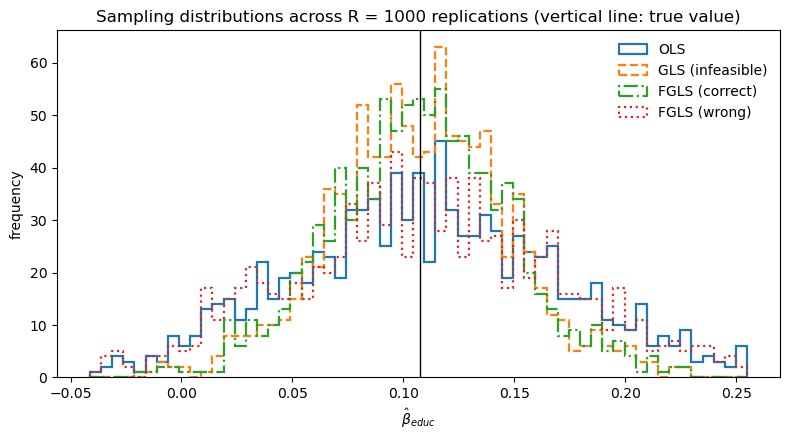

In [11]:
fig, ax = plt.subplots()
bins = np.linspace(*np.percentile(np.concatenate([β_r[l] for l in labels]), [0.5, 99.5]), 60)
for lab, style in zip(labels, ['-', '--', '-.', ':']):
    ax.hist(β_r[lab], bins=bins, histtype='step', linestyle=style, linewidth=1.6, label=lab)
ax.axvline(βtrue_k[k_educ], color='k', linewidth=1.0)
ax.set_xlabel(r'$\hat\beta_{educ}$')
ax.set_ylabel('frequency')
ax.set_title(f'Sampling distributions across R = {R_mc} replications (vertical line: true value)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


The picture makes the variance ranking immediate. The infeasible GLS and correctly-specified FGLS distributions sit on top of each other and are visibly tighter around the true value than OLS; the misspecified FGLS distribution is indistinguishable from the OLS one, for the reason given above: its fitted weights are nearly constant. All four are centred on the vertical line. Consistency is not what separates these estimators; precision is.

# 4. Is reweighting called for? Testing for heteroskedasticity

Before modelling $\Omega$ one should ask whether $\Omega = I$ can be rejected. All the standard tests share one idea: under homoskedasticity the squared residuals are unrelated to the regressors, so *regress the squared residuals on candidate variables and test for joint significance*. They differ in what goes on the right-hand side and how the statistic is normalized.

## 4.1 Breusch–Pagan and Koenker

Breusch and Pagan (1979) test $H_0:\gamma_1=\cdots=\gamma_q=0$ in the variance model $\sigma_i^2 = h(\gamma_0 + z_i^\top\gamma)$ for any smooth $h$: the test statistic does not depend on which $h$. In its original form one regresses the *scaled* squared residuals $\hat\varepsilon_i^2/\tilde\sigma^2$, where $\tilde\sigma^2 = \frac{1}{I}\sum_i\hat\varepsilon_i^2$, on $z_i$ and takes half the explained sum of squares:
$$
LM_{\text{BP}} = \tfrac{1}{2}\,\mathrm{ESS} \;\xrightarrow{d}\; \chi^2_q \quad\text{under } H_0 .
$$
This derivation assumes **Gaussian errors**; the factor $\tfrac{1}{2}$ is $\operatorname{Var}(\varepsilon^2)/\sigma^4 = 2$ turned upside down, and it is wrong under any other kurtosis. Koenker (1981) proposed the studentized version, which replaces the assumed variance of $\varepsilon_i^2$ by its sample counterpart and reduces to
$$
LM_{\text{K}} = I\cdot R^2 \;\xrightarrow{d}\; \chi^2_q ,
$$
where $R^2$ is from the *unscaled* regression of $\hat\varepsilon_i^2$ on $[1, z_i]$. Koenker's version is valid without the normality assumption and is what most software reports by default; the original is more powerful when the errors really are Gaussian.

## 4.2 White's test

White (1980) makes the choice of $z$ automatic: take **all** distinct products of the regressors, levels, squares, and cross-products, as the auxiliary regressors, and compute $I\cdot R^2$ against $\chi^2_p$ with $p$ the number of auxiliary regressors excluding the constant. Its virtue is that it requires no view about the source of heteroskedasticity; its cost is a large $p$ (of order $K^2/2$) and correspondingly low power against any specific alternative, plus the fact that it also picks up certain functional-form errors, so a rejection is not by itself evidence that the variance is the problem.

In [12]:
def bp_koenker_white(X_i_k, εhat_i, Z_i_q=None):
    """Breusch-Pagan, Koenker studentized, and White heteroskedasticity tests."""
    I, K = X_i_k.shape
    if Z_i_q is None:
        Z_i_q = X_i_k
    e2_i = εhat_i ** 2
    σ2t  = e2_i.mean()

    # Breusch-Pagan (Gaussian form): half the explained sum of squares of e²/σ̃² on Z
    g_i  = e2_i / σ2t
    aux  = ols(Z_i_q, g_i)
    ess  = ((aux.yhat_i - g_i.mean()) ** 2).sum()
    q    = Z_i_q.shape[1] - 1
    lm_bp = 0.5 * ess

    # Koenker studentized: I·R² of e² on Z
    aux_k = ols(Z_i_q, e2_i)
    r2_k  = 1 - (aux_k.εhat_i @ aux_k.εhat_i) / ((e2_i - e2_i.mean()) ** 2).sum()
    lm_k  = I * r2_k

    # White: all distinct products of the regressors (constant handled separately)
    Xn_i_k = X_i_k[:, 1:]
    cols = [np.ones(I)] + [Xn_i_k[:, a] for a in range(Xn_i_k.shape[1])]
    for a in range(Xn_i_k.shape[1]):
        for b in range(a, Xn_i_k.shape[1]):
            cols.append(Xn_i_k[:, a] * Xn_i_k[:, b])
    W_i_p = np.column_stack(cols)
    # drop columns that are numerically collinear with earlier ones
    keep, Q = [0], W_i_p[:, [0]]
    for j in range(1, W_i_p.shape[1]):
        resid = W_i_p[:, j] - Q @ np.linalg.lstsq(Q, W_i_p[:, j], rcond=None)[0]
        if np.linalg.norm(resid) > 1e-8 * max(1.0, np.linalg.norm(W_i_p[:, j])):
            keep.append(j); Q = W_i_p[:, keep]
    W_i_p = W_i_p[:, keep]
    aux_w = ols(W_i_p, e2_i)
    r2_w  = 1 - (aux_w.εhat_i @ aux_w.εhat_i) / ((e2_i - e2_i.mean()) ** 2).sum()
    lm_w  = I * r2_w
    p     = W_i_p.shape[1] - 1

    return SimpleNamespace(lm_bp=lm_bp, q=q, lm_k=lm_k, lm_w=lm_w, p=p)

t = bp_koenker_white(X_i_k, fit_ols.εhat_i)
print(f"{'test':<28s}{'statistic':>11s}{'df':>5s}{'p-value':>10s}")
for nm, stat, df in [('Breusch-Pagan (Gaussian)', t.lm_bp, t.q),
                     ('Koenker (studentized)',    t.lm_k, t.q),
                     ('White (all products)',     t.lm_w, t.p)]:
    print(f'{nm:<28s}{stat:>11.4f}{df:>5d}{1 - stats.chi2.cdf(stat, df):>10.4f}')

# Cross-check against statsmodels
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
sm_bp_rob = het_breuschpagan(fit_ols.εhat_i, X_i_k, robust=True)
sm_bp_gau = het_breuschpagan(fit_ols.εhat_i, X_i_k, robust=False)
sm_wh     = het_white(fit_ols.εhat_i, X_i_k)
print(f'\n|DIY Koenker      - sm het_breuschpagan(robust=True)|  = {abs(t.lm_k  - sm_bp_rob[0]):.3e}')
print(f'|DIY Breusch-Pagan - sm het_breuschpagan(robust=False)| = {abs(t.lm_bp - sm_bp_gau[0]):.3e}')
print(f'|DIY White         - sm het_white|                      = {abs(t.lm_w  - sm_wh[0]):.3e}')


test                          statistic   df   p-value
Breusch-Pagan (Gaussian)        34.0835    3    0.0000
Koenker (studentized)           11.7090    3    0.0084
White (all products)            14.1148    8    0.0788

|DIY Koenker      - sm het_breuschpagan(robust=True)|  = 9.415e-14
|DIY Breusch-Pagan - sm het_breuschpagan(robust=False)| = 9.379e-13
|DIY White         - sm het_white|                      = 9.415e-14


The three DIY statistics reproduce their `statsmodels` counterparts to numerical precision, which validates both the implementations and the correspondence claimed in §4.1 (`robust=True` is Koenker's studentized version, `robust=False` the original Gaussian one).

The substantive reading requires care, because **the three tests do not agree**.

* The Gaussian Breusch–Pagan statistic is $34.1$ on 3 degrees of freedom, an emphatic rejection.
* Koenker's studentized version, on the same auxiliary regressors, is $11.7$, still a rejection at the 1% level, but the statistic has fallen by two thirds.
* White's test, with 8 auxiliary regressors, is $14.1$ on 8 degrees of freedom, $p \approx 0.08$: *no rejection at the 5% level*.

The first gap is the more informative of the two, and it is exactly what Koenker's correction was designed to expose. The factor $\tfrac{1}{2}$ in $LM_{\text{BP}}$ is $\sigma^4/\operatorname{Var}(\varepsilon^2)$ evaluated under normality; log-wage residuals have fatter tails than a Gaussian, so $\operatorname{Var}(\varepsilon^2)$ is larger than the normal formula assumes, and the original statistic is inflated. Most of the apparent significance in the Breusch–Pagan line is excess kurtosis being mistaken for heteroskedasticity. **Use the studentized version.**

The second gap is the price of White's agnosticism: spreading the same evidence over 8 auxiliary regressors instead of 3 dilutes the power, and here it is enough to push the test past the 5% line. White's test is the right instrument when one has no view about the source of heteroskedasticity, not when one does.

Taken together, the Mroz Mincer regression displays moderate heteroskedasticity. This clarifies the result in §3.3: the variance *is* related to the regressors, yet the fitted weights turned out barely dispersed and the efficiency gain from FGLS was correspondingly small. **Statistical significance of heteroskedasticity is not the same as material heteroskedasticity**, and only the second is an argument for reweighting. The tests answer the question "is $\Omega = I$ literally true?", to which the answer in economics is essentially always no; the decision-relevant question is how far from $I$ it is, and in which directions.

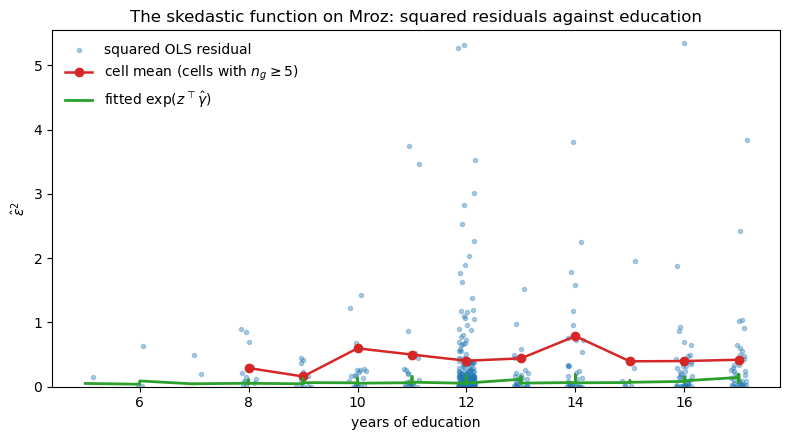

In [13]:
fig, ax = plt.subplots()
order = np.argsort(educ_i)
ax.scatter(educ_i + rng.uniform(-0.15, 0.15, I), fit_ols.εhat_i ** 2, s=9, alpha=0.35,
           label='squared OLS residual')
cell_var = mroz_w.assign(e2=fit_ols.εhat_i ** 2).groupby('educ')['e2'].agg(['mean', 'size'])
big = cell_var['size'] >= 5
ax.plot(cell_var.index[big], cell_var['mean'][big], 'o-', color='C3', linewidth=1.8,
        label='cell mean (cells with $n_g\\geq5$)')
ax.plot(educ_i[order], fit_fgls.σ2hat_i[order], color='C2', linewidth=2.0,
        label=r'fitted $\exp(z^\top\hat\gamma)$')
ax.set_xlabel('years of education')
ax.set_ylabel(r'$\hat\varepsilon^2$')
ax.set_ylim(0, np.percentile(fit_ols.εhat_i ** 2, 99))
ax.set_title('The skedastic function on Mroz: squared residuals against education')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


The plot shows what the tests detect and what FGLS fits. The squared residuals are enormously dispersed at every education level, the vertical spread within a column dwarfs any movement across columns, and the cell means, which average that noise away, drift only gently. The fitted exponential skedastic function tracks that gentle drift and is nearly flat over the range where most of the data lie.

That flatness is the undispersed-weights diagnosis of §3.3 in visual form, and it is why a strongly significant test statistic translated into an almost invisible efficiency gain. It also illustrates why estimating a skedastic function is intrinsically hard: the regression in step 2 of FGLS has $\log\hat\varepsilon_i^2$ as its dependent variable, and that variable carries an irreducible noise term with variance $\pi^2/2 \approx 4.9$ under normality, regardless of sample size. One is fitting a gentle trend through very loud data.

# 5. GLS or robust standard errors?

The two responses to non-spherical errors identified in the motivation can now be compared on equal terms.

| | OLS + robust SE (Lecture 4) | (F)GLS |
| :-- | :-- | :-- |
| Consistency of $\hat\beta$ | needs $\mathbb{E}[x\varepsilon]=0$ | needs $\mathbb{E}[\varepsilon\mid x]=0$ |
| Efficiency | none claimed | BLUE if $\Omega$ correct (Aitken); asymptotically GLS-efficient if $\Omega(\gamma)$ correct |
| If the covariance model is wrong | nothing to be wrong | $\hat\beta$ still consistent, but may be *less* efficient than OLS |
| Validity of the reported SE | valid under any $\Omega$ | valid only if $\Omega$ correct: unless a sandwich is used |
| What must be modelled | nothing | the full covariance structure |

Three practical conclusions follow.

**Robust inference is the default, and it is not a substitute for efficiency.** The profession's shift toward "OLS with clustered standard errors" reflects the top-left cell: it requires no covariance model, and the cost, some lost efficiency, is invisible in any single study, whereas a wrong covariance model produces confidently wrong standard errors that are very visible in aggregate. This is a sound default, and it is why the FGLS literature receded from applied practice after White (1980).

**But there are settings where GLS is not optional.** When the covariance structure is a *known feature of the sampling scheme* rather than a guess, grouped or aggregated data (§2.2), a panel error-components structure (§6), an explicitly modelled dynamic process (§7), or a survey with known design weights, the efficiency loss from ignoring it can be large, and the structure is not being invented.

**The two can be combined, and usually should be.** Nothing forces the weights and the variance estimator to come from the same model. Estimating $\beta$ by FGLS while reporting sandwich standard errors, as verified in the `cov (HC1)` column of §3.4, gives the efficiency of the weighting when the model is right and valid inference when it is wrong. This is the modern recommendation, and its logic, a possibly-misspecified working covariance model, paired with a covariance estimator that does not trust it, is exactly the logic of generalized estimating equations in biostatistics.

> **One caveat that is not about efficiency.** All of the above presumes $\mathbb{E}[\varepsilon\mid x] = 0$, so that OLS and any reweighting estimate the *same* $\beta$. If the linear model is instead the best linear predictor of a nonlinear conditional expectation function, OLS and WLS have different probability limits: each is a differently-weighted approximation to the same CEF. Then the choice of weights is a choice of estimand, not of efficiency, and a comparison of OLS and FGLS coefficients becomes a *specification* diagnostic: large discrepancies are evidence against linearity. This is the same logic as the Hausman comparison in §6.5.

# 6. Error components: random effects as GLS

The most important structured $\Omega$ in economics comes from repeated observations on the same unit. Let $i\in[I]$ index units and $t\in[T]$ time, and write
$$
y_{it} = x_{it}^\top\beta + \alpha_i + \varepsilon_{it},
$$
with $\alpha_i$ an unobserved unit-specific component. The **random-effects** assumption is that $\alpha_i$ is orthogonal to the regressors, $\mathbb{E}[\alpha_i\mid x_{i\bullet}] = 0$, with $\operatorname{Var}(\alpha_i) = \sigma_\alpha^2$, $\operatorname{Var}(\varepsilon_{it}) = \sigma_\varepsilon^2$, and no correlation between the two. Under that assumption the composite error $u_{it} := \alpha_i + \varepsilon_{it}$ leaves pooled OLS consistent, but not efficient, because $u$ is equicorrelated within unit:
$$
\Omega_i = \operatorname{Var}(u_{i\bullet}) = \sigma_\varepsilon^2 I_T + \sigma_\alpha^2\,\iota_T\iota_T^\top ,
\qquad
\operatorname{Corr}(u_{it}, u_{is}) = \frac{\sigma_\alpha^2}{\sigma_\alpha^2 + \sigma_\varepsilon^2} \;\;(t\neq s).
$$
The full covariance is block diagonal, $\Omega = I_I\otimes\Omega_i$ for a balanced panel, a Kronecker structure, so nothing of size $IT\times IT$ ever needs to be formed.

## 6.1 The quasi-demeaning transformation

The matrix $\Omega_i$ has only two distinct eigenvalues, which makes its inverse square root available in closed form. Writing $J_T := \iota_T\iota_T^\top/T$ for the averaging projector and $M_T := I_T - J_T$ for its complement,
$$
\Omega_i = \sigma_\varepsilon^2 M_T + (T\sigma_\alpha^2 + \sigma_\varepsilon^2)\,J_T
\;\;\Longrightarrow\;\;
\Omega_i^{-1/2} = \frac{1}{\sigma_\varepsilon}\Bigl(M_T + \sqrt{\tfrac{\sigma_\varepsilon^2}{T\sigma_\alpha^2+\sigma_\varepsilon^2}}\;J_T\Bigr)
= \frac{1}{\sigma_\varepsilon}\bigl(I_T - \theta J_T\bigr),
$$
where
$$
\boxed{\;\theta := 1 - \sqrt{\frac{\sigma_\varepsilon^2}{T\sigma_\alpha^2 + \sigma_\varepsilon^2}}\;\in[0,1).}
$$
Since $\sigma_\varepsilon^{-1}$ is a common scale factor it drops out of the estimator, so the GLS whitening reduces to the **quasi-demeaning** transformation
$$
y_{it} - \theta\,\bar y_i, \qquad x_{it} - \theta\,\bar x_i ,
$$
followed by OLS. The random-effects estimator is nothing but GLS on the error-components covariance, and $\theta$ is the single number that summarizes it.

The two endpoints are the estimators that panel econometrics is built on:

* $\theta = 0$ (when $\sigma_\alpha^2 = 0$): no transformation, **pooled OLS**.
* $\theta \to 1$ (when $\sigma_\alpha^2/\sigma_\varepsilon^2\to\infty$, or $T\to\infty$): full within-unit demeaning, the **fixed-effects** estimator, which Lecture 7 develops properly.

So FE and pooled OLS are the two limits of a one-parameter family of GLS estimators, and RE sits between them at a $\theta$ dictated by the estimated variance ratio. This is the cleanest way to see why the FE-vs-RE choice is not a choice between two unrelated procedures.

## 6.2 Estimating the variance components

$\theta$ must be estimated, so RE in practice is FGLS. The Swamy–Arora (1972) estimator, which is what most software uses, takes $\sigma_\varepsilon^2$ from the within residuals and backs $\sigma_\alpha^2$ out of the between regression:
$$
\hat\sigma_\varepsilon^2 = \frac{\mathrm{SSR}_{\text{within}}}{IT - I - K_{\text{tv}}},
\qquad
\hat\sigma_{\text{between}}^2 = \frac{\mathrm{SSR}_{\text{between}}}{I - K_{\text{all}}},
\qquad
\hat\sigma_\alpha^2 = \hat\sigma_{\text{between}}^2 - \frac{\hat\sigma_\varepsilon^2}{T},
$$
with $K_{\text{tv}}$ the number of time-varying regressors (excluding the intercept, which the within transformation annihilates) and $K_{\text{all}}$ the number of columns in the between regression. The subtraction can in principle deliver a negative $\hat\sigma_\alpha^2$, in which case it is truncated at zero and RE collapses to pooled OLS.

We use the Vella–Verbeek (1998) wage panel, the dataset of Lecture 7, $I = 545$ young men followed over $T = 8$ years.

In [14]:
import wooldridge
import linearmodels.panel as lp

wagepan = wooldridge.data('wagepan').copy()
df = wagepan.set_index(['nr', 'year']).sort_index()

xvars_tv = ['exper', 'expersq', 'married', 'union']     # time-varying
xvars_ti = ['educ', 'black', 'hisp']                    # time-invariant
Ip = df.index.get_level_values('nr').nunique()
Tp = df.index.get_level_values('year').nunique()
print(f'I = {Ip}, T = {Tp}, IT = {len(df)}, balanced = {len(df) == Ip * Tp}')

y_it = df['lwage'].values
X_it_k = np.column_stack([np.ones(len(df))] + [df[v].values for v in xvars_tv + xvars_ti])
names_re = ['const'] + xvars_tv + xvars_ti
unit_it = df.index.get_level_values('nr').values

def group_means(A, unit, T):
    """Unit means of each column of A, broadcast back to observation level."""
    A2 = np.atleast_2d(A.T).T
    order = np.argsort(unit, kind='stable')
    Asort = A2[order].reshape(-1, T, A2.shape[1])
    means = Asort.mean(axis=1)
    out = np.repeat(means, T, axis=0)
    inv = np.empty_like(order)
    inv[order] = np.arange(len(order))
    return out[inv]

ybar_it = group_means(y_it, unit_it, Tp).ravel()
Xbar_it_k = group_means(X_it_k, unit_it, Tp)

# Within (fixed effects) regression on time-varying regressors only
Xw_it_k = (X_it_k - Xbar_it_k)[:, 1:1 + len(xvars_tv)]
yw_it = y_it - ybar_it
fit_within = ols(Xw_it_k, yw_it)
ssr_w = fit_within.εhat_i @ fit_within.εhat_i
σ2_ε = ssr_w / (Ip * Tp - Ip - len(xvars_tv))

# Between regression on unit means (one observation per unit)
first = np.unique(unit_it, return_index=True)[1]
Xb_g_k, yb_g = Xbar_it_k[first], ybar_it[first]
fit_between = ols(Xb_g_k, yb_g)
ssr_b = fit_between.εhat_i @ fit_between.εhat_i
σ2_between = ssr_b / (Ip - Xb_g_k.shape[1])
σ2_α = max(σ2_between - σ2_ε / Tp, 0.0)

θ = 1 - np.sqrt(σ2_ε / (Tp * σ2_α + σ2_ε))
print(f'\nσ²_ε = {σ2_ε:.5f}   σ²_α = {σ2_α:.5f}   ratio σ²_α/σ²_ε = {σ2_α/σ2_ε:.4f}')
print(f'intraclass correlation = {σ2_α/(σ2_α+σ2_ε):.4f}')
print(f'θ = {θ:.5f}')


I = 545, T = 8, IT = 4360, balanced = True

σ²_ε = 0.12338   σ²_α = 0.10534   ratio σ²_α/σ²_ε = 0.8538
intraclass correlation = 0.4606
θ = 0.64264


## 6.3 Two routes to the random-effects estimator

Quasi-demeaning is a shortcut; the definition is GLS with the block-diagonal $\Omega$. Computing both and comparing is the verification this section needs: if the closed form for $\Omega_i^{-1/2}$ in §6.1 were wrong, the two would disagree.

The direct route never forms the $4360\times4360$ matrix $\Omega$: it accumulates $X^\top\Omega^{-1}X = \sum_i X_i^\top\Omega_i^{-1}X_i$ over units, using the $T\times T$ block.

In [15]:
# Route 1: quasi-demeaning
Xq_it_k = X_it_k - θ * Xbar_it_k
yq_it = y_it - θ * ybar_it
fit_re_quasi = ols(Xq_it_k, yq_it)

# Route 2: block GLS, accumulating over units with the T x T block Ω_i
Ωi_t_t = σ2_ε * np.eye(Tp) + σ2_α * np.ones((Tp, Tp))
Ωinv_t_t = np.linalg.inv(Ωi_t_t)
order = np.argsort(unit_it, kind='stable')
X3 = X_it_k[order].reshape(Ip, Tp, -1)
y3 = y_it[order].reshape(Ip, Tp)
A_k_k = np.einsum('itk,ts,isl->kl', X3, Ωinv_t_t, X3)
b_k   = np.einsum('itk,ts,is->k',   X3, Ωinv_t_t, y3)
β_re_block_k = np.linalg.solve(A_k_k, b_k)

print(f'max |RE(quasi-demeaning) - RE(block GLS)| = '
      f'{np.max(np.abs(fit_re_quasi.β_k - β_re_block_k)):.3e}')

# Route 3: the library
re_res = lp.RandomEffects(df['lwage'], df[['exper', 'expersq', 'married', 'union',
                                           'educ', 'black', 'hisp']].assign(const=1.0)).fit()
lib_k = np.array([re_res.params['const']] + [re_res.params[v] for v in xvars_tv + xvars_ti])
print(f'max |DIY RE - linearmodels.RandomEffects|  = {np.max(np.abs(fit_re_quasi.β_k - lib_k)):.3e}')
print(f'θ (DIY) = {θ:.6f}   θ (linearmodels) = {re_res.theta.values[0, 0]:.6f}')


max |RE(quasi-demeaning) - RE(block GLS)| = 2.543e-11
max |DIY RE - linearmodels.RandomEffects|  = 1.689e-05
θ (DIY) = 0.642641   θ (linearmodels) = 0.642500


The two DIY routes agree to $2.5\times10^{-11}$: the closed form for $\Omega_i^{-1/2}$ in §6.1 is exact, and quasi-demeaning really is block GLS.

Against `linearmodels` the agreement is only to $1.7\times10^{-5}$, and the last line locates the reason: the library's $\theta$ is $0.642500$ against our $0.642641$. Both implement Swamy–Arora; they differ in one small-sample convention. Our within regression estimates 4 slopes (the 3 time-invariant regressors having been annihilated by the transformation) and so divides its residual sum of squares by $IT - I - K_{\text{tv}} = 4360 - 545 - 4 = 3811$; `linearmodels` charges degrees of freedom for all 7 regressors and divides by $3808$. The between-variance components agree exactly, so this is the whole of the difference.

The discrepancy is four orders of magnitude below the standard errors of the coefficients and changes no conclusion, but it should be reported: a variance-component estimator is a small-sample convention, not a theorem, and two defensible conventions give two slightly different $\hat\theta$. The asymptotic theory is silent here: every version of $\hat\theta$ is consistent for the same $\theta$, so nothing in §6.1 distinguishes them.

## 6.4 The $\theta$ path: pooled OLS, RE, and FE as one family

With $\theta$ in hand we can trace the family of §6.1 explicitly, computing the quasi-demeaned estimator at $\theta = 0$ (pooled OLS), at the estimated $\hat\theta$ (RE), and at $\theta = 1$ (within/FE). Only the time-varying coefficients can be compared across all three: at $\theta = 1$ the time-invariant regressors are annihilated by the transformation, which is exactly why fixed effects cannot identify the return to education in this panel.

In [16]:
def quasi_demeaned_fit(θ_val, cols):
    Xq = (X_it_k - θ_val * Xbar_it_k)[:, cols]
    yq = y_it - θ_val * ybar_it
    return ols(Xq, yq)

k_tv = [names_re.index(v) for v in xvars_tv]
rows = [('pooled OLS (θ=0)', 0.0), (f'RE (θ={θ:.3f})', θ), ('within/FE (θ=1)', 1.0)]

print(f"{'':<20s}" + ''.join(f'{v:>11s}' for v in xvars_tv) + f"{'educ':>11s}")
for label, θv in rows:
    if θv < 1.0:
        f = quasi_demeaned_fit(θv, list(range(len(names_re))))
        educ_txt = f'{f.β_k[names_re.index("educ")]:>11.4f}'
        tv = [f.β_k[k] for k in k_tv]
    else:
        f = quasi_demeaned_fit(1.0, k_tv)     # time-invariant columns are identically zero
        educ_txt = f'{"—":>11s}'
        tv = list(f.β_k)
    print(f'{label:<20s}' + ''.join(f'{b:>11.4f}' for b in tv) + educ_txt)

print(f'\nAt θ=1 the time-invariant regressors are annihilated: '
      f'max |educ - θ·educ_bar| = {np.max(np.abs((X_it_k - 1.0*Xbar_it_k)[:, names_re.index("educ")])):.3e}')


                          exper    expersq    married      union       educ
pooled OLS (θ=0)         0.0892    -0.0028     0.1077     0.1801     0.0994
RE (θ=0.643)             0.1121    -0.0041     0.0628     0.1074     0.1012
within/FE (θ=1)          0.1168    -0.0043     0.0453     0.0821          —

At θ=1 the time-invariant regressors are annihilated: max |educ - θ·educ_bar| = 0.000e+00


The estimated $\hat\theta = 0.64$ sits squarely inside $(0,1)$: with $T = 8$ and an intraclass correlation of $0.46$, GLS elects to demean about two thirds of the way. The coefficient path is not linear in $\theta$, and the table shows where the RE estimates actually land: roughly three quarters of the way from pooled OLS to the within estimator for every time-varying coefficient. In this panel, GLS is much closer to fixed effects than to pooling.

The economically interesting movement is on `married` and `union`, whose coefficients fall by nearly half between pooled OLS and FE ($0.108\to0.045$ and $0.180\to0.082$). Pooled OLS attributes to marriage and union membership a wage premium that fixed effects assigns instead to the time-invariant characteristics of the men who marry and unionize. RE splits the difference, which is the right thing to do *if* those characteristics are uncorrelated with the regressors, and the wrong thing to do otherwise. That is the question the Hausman test answers.

The last line confirms the annihilation claim: at $\theta = 1$ the education column of the transformed design is identically zero to machine precision, so the return to education is simply not identified by the within estimator.

In [17]:
# FE and RE on the same time-varying regressors, each with its own classical variance
fit_fe = ols((X_it_k - Xbar_it_k)[:, k_tv], y_it - ybar_it)
V_fe_k_k = σ2_ε * fit_fe.XtXinv_k_k                                    # dof-corrected σ²_ε from §6.2
fit_re = fit_re_quasi
V_re_full = fit_re.σ2 * fit_re.XtXinv_k_k
V_re_k_k = V_re_full[np.ix_(k_tv, k_tv)]

d_k = fit_fe.β_k - fit_re.β_k[k_tv]
D_k_k = V_fe_k_k - V_re_k_k
λ_k = np.linalg.eigvalsh(D_k_k)
psd = bool(np.all(λ_k > 0))
print(f'eigenvalues of Var(FE) - Var(RE): {np.array2string(λ_k, precision=8)}')
print(f'positive definite? {psd}')

Dinv_k_k = np.linalg.inv(D_k_k) if psd else np.linalg.pinv(D_k_k)
H = float(d_k @ Dinv_k_k @ d_k)
dfH = len(k_tv) if psd else int(np.sum(λ_k > 1e-12))
print(f'\n{"":<12s}{"FE":>11s}{"RE":>11s}{"difference":>13s}{"se(diff)":>11s}')
for j, v in enumerate(xvars_tv):
    print(f'{v:<12s}{fit_fe.β_k[j]:>11.4f}{fit_re.β_k[k_tv[j]]:>11.4f}'
          f'{d_k[j]:>13.4f}{np.sqrt(D_k_k[j, j]):>11.4f}')
print(f'\nHausman H = {H:.3f} on {dfH} df,  p = {1 - stats.chi2.cdf(H, dfH):.3e}')


eigenvalues of Var(FE) - Var(RE): [9.86473667e-10 1.88853079e-06 5.37649278e-05 5.51491103e-05]
positive definite? True

                     FE         RE   difference   se(diff)
exper            0.1168     0.1121       0.0047     0.0016
expersq         -0.0043    -0.0041      -0.0002     0.0001
married          0.0453     0.0628      -0.0175     0.0073
union            0.0821     0.1074      -0.0253     0.0074

Hausman H = 31.451 on 4 df,  p = 2.476e-06


The sample variance difference is positive definite here, so no generalized inverse is needed, and the test rejects the random-effects orthogonality assumption decisively: $H = 31.5$ on 4 degrees of freedom, $p\approx 2\times10^{-6}$.

The `difference` column locates the rejection. All four coefficients contribute, each differs by roughly 2.5 to 3.5 times the standard error of its own difference, but `married` and `union` carry the largest absolute gaps, $-0.018$ and $-0.025$ in log points. The economic reading is the standard one for this dataset: men who marry or join a union differ in unobserved, time-invariant ways, ability, taste for stable employment, local labour-market attachment, that are correlated with the regressors. The RE assumption fails, and the efficiency it offers is bought with bias.

This is the general shape of the trade-off that GLS forces on the applied researcher, and it can be stated in the terms of §5: **efficiency assumptions are testable against the estimator that does not make them**. When the test rejects, the efficient estimator is not merely less trustworthy: it is estimating something else.

> **Where this goes.** Lecture 7 develops the fixed-effects estimator on its own terms: the within transformation as Frisch–Waugh partialling-out, the least-squares-dummy-variable equivalence, first differences, time effects, and cluster-robust inference for panels. This section supplies the piece of the story that belongs to GLS: RE is the efficient estimator under a stronger assumption, FE is the $\theta\to1$ limit that survives without it, and the Hausman statistic is the referee.

# 7. Serial correlation: the AR(1) case

The other classical departure from sphericity is serial correlation in time-series data. Suppose
$$
y_t = x_t^\top\beta + \varepsilon_t, \qquad \varepsilon_t = \rho\,\varepsilon_{t-1} + u_t, \qquad |\rho| < 1,
$$
with $u_t$ i.i.d. of variance $\sigma_u^2$. The stationary error process has autocovariances $\operatorname{Cov}(\varepsilon_t,\varepsilon_s) = \sigma_u^2\rho^{|t-s|}/(1-\rho^2)$, so
$$
\Omega = \frac{1}{1-\rho^2}\begin{pmatrix}
1 & \rho & \cdots & \rho^{T-1}\\
\rho & 1 & \cdots & \rho^{T-2}\\
\vdots & & \ddots & \vdots\\
\rho^{T-1} & \rho^{T-2} & \cdots & 1
\end{pmatrix},
$$
a Toeplitz matrix with a sparse inverse. The whitening transformation is available in closed form and is called the **Prais–Winsten** transformation:
$$
\tilde y_1 = \sqrt{1-\rho^2}\;y_1, \qquad \tilde y_t = y_t - \rho\,y_{t-1}\;\;(t\ge2),
$$
and identically for each column of $X$. **Cochrane–Orcutt** is the same transformation with the first observation dropped rather than rescaled; the two differ by one observation, which is asymptotically irrelevant and can matter noticeably when $T$ is small or $\rho$ close to one.

In [18]:
def prais_winsten(A, ρ, drop_first=False):
    """Prais-Winsten whitening of a vector or matrix of time-series observations."""
    A2 = np.atleast_2d(A.T).T
    out = A2.copy()
    out[1:] = A2[1:] - ρ * A2[:-1]
    out[0] = np.sqrt(1 - ρ ** 2) * A2[0]
    if drop_first:
        out = out[1:]
    return out.ravel() if A.ndim == 1 else out

def ar1_Ω(T, ρ):
    d = np.abs(np.subtract.outer(np.arange(T), np.arange(T)))
    return ρ ** d / (1 - ρ ** 2)

# One simulated series, to verify the transformation against the dense GLS formula
T, ρ_true = 200, 0.8
rng_ts = np.random.default_rng(7)
x_t = np.empty(T); x_t[0] = rng_ts.standard_normal()
for t in range(1, T):
    x_t[t] = 0.7 * x_t[t - 1] + rng_ts.standard_normal()     # persistent regressor
Xts_t_k = np.column_stack([np.ones(T), x_t])
βts_k = np.array([1.0, 0.5])
ε_t = np.empty(T); ε_t[0] = rng_ts.standard_normal() / np.sqrt(1 - ρ_true ** 2)
for t in range(1, T):
    ε_t[t] = ρ_true * ε_t[t - 1] + rng_ts.standard_normal()
y_t = Xts_t_k @ βts_k + ε_t

β_dense = gls_direct(Xts_t_k, y_t, ar1_Ω(T, ρ_true)).β_k
β_pw    = ols(prais_winsten(Xts_t_k, ρ_true), prais_winsten(y_t, ρ_true)).β_k
β_co    = ols(prais_winsten(Xts_t_k, ρ_true, drop_first=True),
              prais_winsten(y_t, ρ_true, drop_first=True)).β_k
print(f'max |Prais-Winsten - dense GLS| = {np.max(np.abs(β_pw - β_dense)):.3e}')
print(f'max |Cochrane-Orcutt - dense GLS| = {np.max(np.abs(β_co - β_dense)):.3e}   (differs by one observation)')


max |Prais-Winsten - dense GLS| = 1.221e-15
max |Cochrane-Orcutt - dense GLS| = 7.504e-02   (differs by one observation)


The Prais–Winsten transformation reproduces the dense GLS estimator to machine precision: the closed form for $\Omega^{-1/2}$ is exact, and the $T\times T$ matrix never needs to be built.

Cochrane–Orcutt, by contrast, differs from GLS by $0.075$ on a slope of $0.5$. That is far larger than one might expect from discarding a single observation out of $200$, and the reason is the following. After the transformation, the intercept column equals $1-\rho = 0.2$ for every $t\ge2$ and $\sqrt{1-\rho^2} = 0.6$ for $t=1$. The first observation is therefore the *only* one that carries any variation in that column: it is a high-leverage point by construction, and dropping it changes the estimate by about one standard error of the estimator itself (§7's Monte Carlo puts that standard error at $0.073$). This is exactly why Prais–Winsten is preferred to Cochrane–Orcutt, and why the preference matters most in the small-$T$, high-$\rho$ settings where the transformed first observation carries the most weight.

In [19]:
def vcov_hac(X_t_k, εhat_t, L):
    """Newey-West HAC sandwich with Bartlett kernel and L lags."""
    T, K = X_t_k.shape
    S_t_k = X_t_k * εhat_t[:, None]
    Γ0 = S_t_k.T @ S_t_k
    Ω_k_k = Γ0.copy()
    for j in range(1, L + 1):
        Γj = S_t_k[j:].T @ S_t_k[:-j]
        Ω_k_k += (1 - j / (L + 1)) * (Γj + Γj.T)
    B_k_k = np.linalg.inv(X_t_k.T @ X_t_k)
    return (T / (T - K)) * B_k_k @ Ω_k_k @ B_k_k

def simulate_ar1(T, ρ, rng):
    x = np.empty(T); x[0] = rng.standard_normal()
    for t in range(1, T):
        x[t] = 0.7 * x[t - 1] + rng.standard_normal()
    X = np.column_stack([np.ones(T), x])
    ε = np.empty(T); ε[0] = rng.standard_normal() / np.sqrt(1 - ρ ** 2)
    for t in range(1, T):
        ε[t] = ρ * ε[t - 1] + rng.standard_normal()
    return X, X @ βts_k + ε

rng_ts = np.random.default_rng(11)
R_ts, T_ts, L_nw = 1_000, 200, 6
Ω_fixed = ar1_Ω(T_ts, ρ_true)
βhat = {k: np.empty(R_ts) for k in ['OLS', 'PW (feasible)', 'GLS (infeasible)']}
cov = {k: 0 for k in ['OLS classical', 'OLS HC1', 'OLS Newey-West', 'PW classical']}
z_crit = stats.norm.ppf(0.975)
k_slope = 1

for r in range(R_ts):
    Xs, ys = simulate_ar1(T_ts, ρ_true, rng_ts)
    f0 = ols(Xs, ys)
    ρhat = float(np.corrcoef(f0.εhat_i[1:], f0.εhat_i[:-1])[0, 1])
    fpw = ols(prais_winsten(Xs, ρhat), prais_winsten(ys, ρhat))
    fgl = gls_direct(Xs, ys, Ω_fixed)
    βhat['OLS'][r], βhat['PW (feasible)'][r], βhat['GLS (infeasible)'][r] = (
        f0.β_k[k_slope], fpw.β_k[k_slope], fgl.β_k[k_slope])

    ses = {'OLS classical':  np.sqrt(f0.V_k_k[k_slope, k_slope]),
           'OLS HC1':        np.sqrt(vcov_robust_weighted(Xs, f0.εhat_i, np.ones(T_ts))[k_slope, k_slope]),
           'OLS Newey-West': np.sqrt(vcov_hac(Xs, f0.εhat_i, L_nw)[k_slope, k_slope]),
           'PW classical':   np.sqrt(fpw.V_k_k[k_slope, k_slope])}
    for lab, se in ses.items():
        b = fpw.β_k[k_slope] if lab.startswith('PW') else f0.β_k[k_slope]
        cov[lab] += abs(b - βts_k[k_slope]) <= z_crit * se

print(f'AR(1) errors, ρ = {ρ_true}, T = {T_ts}, R = {R_ts}, Newey-West lags L = {L_nw}\n')
print(f"{'estimator':<20s}{'mean':>9s}{'sd':>9s}{'rel. eff.':>11s}")
sd0 = βhat['OLS'].std(ddof=1)
for lab in ['OLS', 'PW (feasible)', 'GLS (infeasible)']:
    sd = βhat[lab].std(ddof=1)
    print(f'{lab:<20s}{βhat[lab].mean():>9.4f}{sd:>9.4f}{(sd/sd0)**2:>11.3f}')
print(f'\n{"CI procedure":<20s}{"coverage of nominal 95%":>26s}')
for lab in ['OLS classical', 'OLS HC1', 'OLS Newey-West', 'PW classical']:
    print(f'{lab:<20s}{cov[lab]/R_ts:>26.3f}')


AR(1) errors, ρ = 0.8, T = 200, R = 1000, Newey-West lags L = 6

estimator                mean       sd  rel. eff.
OLS                    0.4943   0.1579      1.000
PW (feasible)          0.4992   0.0727      0.212
GLS (infeasible)       0.4989   0.0724      0.210

CI procedure           coverage of nominal 95%
OLS classical                            0.700
OLS HC1                                  0.683
OLS Newey-West                           0.873
PW classical                             0.942


The efficiency table shows the largest gains in this lecture: with a persistent regressor and $\rho = 0.8$, modelling the serial correlation removes almost 80% of the sampling variance of the slope, and the feasible Prais–Winsten estimator, which has to estimate $\rho$ from the residuals, captures essentially all of the infeasible gain. Serial correlation is where GLS earns its keep, far more than heteroskedasticity, where §2 and §3 found gains of a few percent on the skedastic function the data actually support.

The coverage table delivers the inference counterpart, and two of its lines deserve emphasis.

**HC1 is no better than the classical standard error here**: 68% against 70%, both catastrophically below the nominal 95%. The heteroskedasticity-robust sandwich of Lecture 4 corrects the *diagonal* of the covariance filling and says nothing about the off-diagonal terms that serial correlation puts there. A robust standard error is robust only to what it was built to be robust to; "robust" is not a general-purpose insurance policy, and using an HC estimator on serially correlated data is a common and costly error.

**Newey–West improves matters substantially but does not fix them**: coverage rises to 87%, still eight points short. HAC estimators are consistent, but at $T = 200$ with $\rho = 0.8$ and $L = 6$ lags the estimated autocovariances are noisy and the truncation discards real dependence beyond lag 6; the well-documented consequence is downward-biased standard errors in exactly this regime. Prais–Winsten with its classical standard error, by contrast, covers at 94%: when the dependence structure is correctly modelled, there is no autocorrelation left in the whitened data for a HAC correction to accommodate.

This is the same complementarity as in §5, now in the time dimension, and with the balance tipped further toward modelling. The choice of $L$ is the one free parameter, and the HAC literature, Newey and West (1987) and its many refinements, is largely about choosing it well.

# Summing up

* **GLS is OLS in a different inner product.** Whitening by any $P$ with $P^\top P = \Omega^{-1}$ turns a non-spherical model into a spherical one, and every result of Lecture 3 transfers to it unchanged. Aitken's theorem is Gauss–Markov after a change of coordinates, and it locates rather than contradicts the earlier result: OLS is BLUE exactly in the model whose errors are spherical.

* **The efficiency gain is governed by the dispersion of the weights, not by the significance of a test.** On Mroz, heteroskedasticity is detected by the studentized Breusch–Pagan test but not by White's, the estimated skedastic function is gentle, the fitted weights span only 5 to 1, and FGLS moves the standard errors by single-digit percentages. On AR(1) data with $\rho = 0.8$, by contrast, GLS removes almost 80% of the sampling variance. Serial correlation and grouped sampling are where reweighting pays; mild heteroskedasticity is not.

* **Weights are a modelling choice with a cost when wrong.** FGLS with a misspecified skedastic function stays consistent but gains nothing, and its classical standard errors remain invalid. Pairing weights with a sandwich is the remedy: with the caveat that correct weighting has its own finite-sample cost, since dispersed weights shrink the effective sample size and leave a residual under-coverage that no variance estimator removes.

* **Two standard estimators are GLS in disguise.** Random effects is GLS on the error-components covariance, with the quasi-demeaning parameter $\theta$ interpolating between pooled OLS ($\theta=0$) and fixed effects ($\theta\to1$); Prais–Winsten is GLS on the AR(1) covariance. Recognizing them as such explains both what they buy and what they assume, and on the Vella–Verbeek panel the Hausman test rejects the random-effects assumption outright, so the efficient estimator is the wrong one.

* **The economic content of a covariance matrix.** $\Omega$ is not a technical nuisance: it encodes how the data were generated and gathered. Cell means carry variance $\sigma^2/n_g$ because they average $n_g$ people; panel errors are equicorrelated because the same person carries the same unobserved ability from year to year; the returns to union membership look different under FE and RE because that ability is correlated with who joins a union. Modelling $\Omega$ is modelling the sampling scheme, and the estimator that ignores it is discarding information about how the world produced the numbers.

# Looking ahead

Generalized least squares completes the finite-sample theory of the linear model begun in Lecture 3: the Gauss–Markov theorem and its Aitken generalization now cover both spherical and non-spherical errors, and Lecture 4's robust standard errors provide the alternative route when the covariance structure is unknown.

* The next lecture (**Lecture 6, the delta method and Wald tests**) returns to inference on functions of $\hat\beta$. Nothing there depends on how $\hat\beta$ was weighted: a Gaussian limit and a consistent variance estimator are all the delta method and the Wald statistic ever need, whether the estimator is OLS, WLS, or FGLS.

* **Lecture 7 (panel data)** develops the fixed-effects estimator that appeared here as the $\theta\to1$ limit: the within transformation, its Frisch–Waugh interpretation, LSDV equivalence, first differences, and cluster-robust inference. The random-effects estimator and the Hausman test of §6 are its counterpart under the stronger orthogonality assumption.

* In **Lecture 9 (GMM)** the same idea reappears one level up. GMM chooses a weight matrix for a vector of sample moments, and the efficient choice is the inverse of the moments' covariance: precisely the GLS logic, with moment conditions in place of observations. Two-step efficient GMM is to the method of moments what FGLS is to least squares, including the caveat that the estimated weight matrix must be estimated well enough for the promised efficiency to materialize.